# Cell Migration RTM Pipeline
This notebook showcases an example how to do directed migration as shown in the real-time feedback microscopy paper. The frontal part of the cells are stimulated using a DMD. The Demo is adapted to run on our Ti2 microscope called Niesen (see our [Mic config repository](https://github.com/pertzlab/pertzlab_mic_configs) for the full configuration file). 

### Import required libraries

In [ ]:
%load_ext autoreload
%autoreload 2
import os
import time
from faro.core.data_structures import Channel, StimTreatment, SegmentationMethod
import faro.core.utils as utils
from pprint import pprint
import pandas as pd
import numpy as np

### Experimental Settings

In [ ]:
from faro.microscope.pertzlab.moench import Moench

mic = Moench()
mic.mmc.setChannelGroup("TTL_ERK")

In [ ]:
## Configuration options - set experiment timing, storage and stimulation parameters
# General timing and frame counts:
N_FRAMES = 30 * 4  # number of timesteps
# If you want the notebook/script to wait before starting the experiment, set this (hours).
# Useful for scheduling: set to a fractional value (e.g. 0.5 for 30 minutes).
SLEEP_BEFORE_EXPERIMENT_START_in_H = 0

# Timing for acquisition: interval between timesteps (seconds) and approximate time per FOV (seconds).
# TIME_BETWEEN_TIMESTEPS: time between frames (across all FOVs).
TIME_BETWEEN_TIMESTEPS = 15  # seconds between timesteps
# TIME_PER_FOV: approximate time required to image one FOV (used for scheduling/estimates).
TIME_PER_FOV = 3.75  # seconds per FOV (camera + stage moves + overhead)

# Display / bookkeeping options:
# If True, add a column/group that stores the last stimulation exposure applied to each FOV (helpful for QC).
ADD_STIM_EXPOSURE_GROUP = False  # set to True to save per-FOV last-stim-exposure info
# When True, stim timepoints will be distributed evenly across the available timesteps rather than using explicit lists.
REGULAR_SPACING_BETWEEN_STIMULATIONS = False  # True -> evenly spaced stim timings; False -> use explicit stim_timestep lists

## Storage path for the experiment - change to your desired directory and experiment name.
base_path = "E:\\Alex"  # example: 'E:\Alex' (double-escaped for JSON/Notebook)
experiment_name = "testmigration2"
path = os.path.join(base_path, experiment_name)

## Channels: images to acquire each timestep.
# Each Channel(...) maps to a microscope channel name configured in Micro-Manager/your device.
# If exposure or power is omitted, the hardware default (set in the device/GUI) will be used.
# Examples: specify different exposures per channel, or add channels without exposures to use defaults.
channels = []
channels.append(Channel(config="mScarlet3", exposure=200))  # example: ERK-KTR reporter

# Optional channel to run an optocheck (check expression of optogenetic marker).
# If the optogenetic marker is imaged in the same channel as stimulation, you can reuse that channel here.
channel_optocheck = Channel(
    config="mCitrine", exposure=200
)  # high exposure for low-signal marker
optocheck_timepoints = (
    N_FRAMES - 1,
)  # tuple of timesteps at which to capture the optocheck channel

# Experimental condition(s): a list of labels assigned to FOVs.
# You can repeat or expand this list to match the number of FOVs.
condition = [
    "optoTIAM_single",
]
# Example alternatives (uncomment to use):
# - Repeat each condition multiple times: condition = [cond for cond in condition for _ in range(repeats)]
# - Create a long condition vector: condition = ["optoFGFR_high"] * 24 + ["optoFGFR"] * 24

# If using wellplates, set how many FOVs per well. Set to None if not using wellplates.
n_fovs_per_well = None  ## number of FOVs per well; use None for free-FOV experiments

# Stimulation parameters for optogenetics. Define a list of StimTreatment objects per phase.
# Notes on StimTreatment fields:
# - treatment_name: human-readable label for the treatment
# - stim_timestep: a tuple/list of integers (timesteps) when stimulation should occur, OR a range/tuple.
#       Examples: (10,20,30), list(range(10,100)), (tuple(range(10,100,1)))
# - stim_exposure_list: either a single exposure value (applied to all listed timesteps) or a list/tuple of exposures matching the timesteps.
# - auto_repeat_stim_exposure: when True and a single exposure value is provided, it will be repeated across timesteps.
# - stim_power/stim_channel_name/stim_channel_group: map the stimulation settings to your device/channel group.
# - stim_channel_device_name/stim_channel_power_property_name: lower-level device settings used by the hardware API.

stim_phase = [
    StimTreatment(
        treatment_name="15min_stim",
        stim_timestep=(tuple(range(1, 30 * 4, 1))),  # example: stim at timesteps 10..99
        stim_exposure_list=200,
        stim_power=10,
        stim_channel_name="CyanStim",
        stim_channel_group="TTL_ERK",
        stim_channel_device_name="Spectra",
        stim_channel_power_property_name="Cyan_Level",
        auto_repeat_stim_exposure=True,
    )
]

# a list of StimTreatment objects; when multiple are supplied they will be assigned across FOVs according to the utils.apply_stim_treatments_to_df_acquire logic

# # Print the final stim schedule for confirmation before running. Helpful to verify exposures/timings.
# for stim_phase in [
#     stim_phase,
# ]:
#     utils.print_stim_exposures_timesteps(stim_phase)

## Define the Tools that you are using for the experiment (segmentors, trackers, feature extractors, stimulator).
from faro.stimulation.percentage_of_cell import StimPercentageOfCell
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.simple import SimpleFE
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.remote import SegmentatorImagingServerKit
from faro.segmentation.remote import SegmentatorImagingServerKit


segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=SegmentatorImagingServerKit(
            server="http://izbniesen.izb.unibe.ch:8001",
            algorithm="StarDist (2D)",
            min_size=50,
        ),
        use_channel=0,
        save_tracked=True,
    )
]

stimulator = StimPercentageOfCell()
feature_extractor = SimpleFE("labels")
tracker = TrackerTrackpy()
optocheck = OptoCheckFE(used_mask="labels")


from faro.core.pipeline import ImageProcessingPipeline

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=feature_extractor,
    tracker=tracker,
    stimulator=stimulator,
    feature_extractor_optocheck=optocheck,
)

#### Demonstartion of stimulation engine on old experiment / frame

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


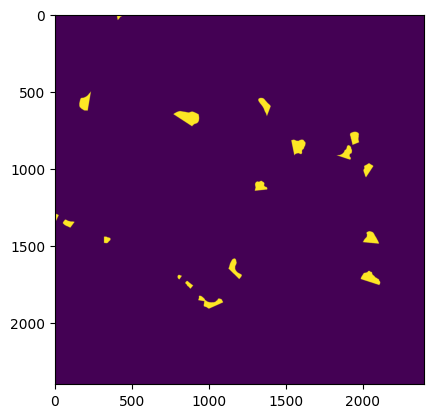

In [4]:
%load_ext autoreload
%autoreload 2
import os
import tifffile

metadata = {
    "stim_cell_percentage": 0.3,
}

base_path = "E:\\Alex"  # example: 'E:\Alex' (double-escaped for JSON/Notebook)
experiment_name = "testmigration"
path = os.path.join(base_path, experiment_name)

raw = tifffile.imread(os.path.join(path, "raw", "000_00000.tiff"))
labels = tifffile.imread(os.path.join(path, "labels", "000_00000.tiff"))
labels = {"labels": labels}  # convert to dict for feature extractor

from faro.stimulation.percentage_of_cell import StimPercentageOfCell

stimulator_test = StimPercentageOfCell()

import matplotlib.pyplot as plt

stimmask, _ = stimulator_test.get_stim_mask(labels, metadata=metadata)

plt.imshow(stimmask)

### GUI - Napari Micromanager

#### Load GUI

In [6]:
### Base GUI ###
from napari_micromanager import MainWindow
import napari

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc
viewer.window.add_dock_widget(mm_wdg)
data_mda_fovs = None
load_from_file = False

Please execute the following code block, if you would like to set a custom ROI (e.g. smaller illumination than the full field of view of the camera). Execute it after you have started the camera once in the GUI. 

In [ ]:
if mic.SET_ROI_REQUIRED:
    mic.mmc.clearROI()
    mic.mmc.setROI(mic.ROI_X, mic.ROI_Y, mic.ROI_WIDTH, mic.ROI_HEIGHT)


DMD calibration

In [ ]:
try:
    mm_wdg._core_link.cleanup()
except Exception as e:
    print(e)
import pymmcore_plus

pymmcore_plus.configure_logging(
    stderr_level="CRITICAL",
)
mic.calibrate_dmd(verbose=True, exposure=100, radius=4, n_points=15)
from napari_micromanager._core_link import CoreViewerLink

mm_wdg._core_link = CoreViewerLink(viewer, mic.mmc)

If required skip calibration step and use old affine transformation matrix

In [ ]:
# np.save("affine.npy", mic.dmd.affine)
mic.dmd.affine = np.load("affine.npy")

### Map Experiment to FOVs

### Use FOVs to generate dataframe for acquisition

In [25]:
fovs = utils.generate_fov_objects(mic, viewer=viewer)


df_acquire = utils.generate_df_acquire(
    fovs,
    n_frames=N_FRAMES,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    time_per_fov=TIME_PER_FOV,
    channels=channels,
    condition=condition,
)
df_acquire = utils.apply_stim_treatments_to_df_acquire(
    df_acquire,
    stim_phase,
    condition,
    n_fovs_per_well=n_fovs_per_well,
    add_stim_exposure_group=ADD_STIM_EXPOSURE_GROUP,
    regular_spacing_between_stimulations=REGULAR_SPACING_BETWEEN_STIMULATIONS,
)
df_acquire

c:\micromanager_faro\faro\faro\utils.py:178: FutureWarning: The `_dock_widgets` property is private and should not be used in any plugin code. Please use the `dock_widgets` property instead.
  data_mda_fovs = viewer.window._dock_widgets["MDA"].widget().value().stage_positions


Total Experiment Time: 0.49583333333333335h
Doing 4 experiment per stim condition


,fov_object,fov,fov_x,fov_y,fov_name,timestep,time,channels,fname,cell_line,treatment_name,stim_timestep,stim_exposure_list,stim_power,stim_channel_name,stim_channel_group,stim_channel_device_name,stim_channel_power_property_name,stim_exposure,stim
0,<faro.core.data_structures.Fov object at 0x...,0,16882.5,-4572.5,0,0,0.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",000_00000,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,0.0,False
1,<faro.core.data_structures.Fov object at 0x...,1,16142.9,-7830.6,1,0,0.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",001_00000,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,0.0,False
2,<faro.core.data_structures.Fov object at 0x...,2,18746.8,-4591.0,2,0,0.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",002_00000,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,0.0,False
3,<faro.core.data_structures.Fov object at 0x...,3,15342.1,-6676.5,3,0,0.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",003_00000,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,0.0,False
4,<faro.core.data_structures.Fov object at 0x...,0,16882.5,-4572.5,0,1,15.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",000_00001,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,200.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,<faro.core.data_structures.Fov object at 0x...,3,15342.1,-6676.5,3,118,1770.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",003_00118,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,200.0,True
476,<faro.core.data_structures.Fov object at 0x...,0,16882.5,-4572.5,0,119,1785.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",000_00119,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,200.0,True
477,<faro.core.data_structures.Fov object at 0x...,1,16142.9,-7830.6,1,119,1785.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",001_00119,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,200.0,True
478,<faro.core.data_structures.Fov object at 0x...,2,18746.8,-4591.0,2,119,1785.0,"({'name': 'mScarlet3', 'exposure': 200, 'group...",002_00119,optoTIAM_single,15min_stim,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(200, 200, 200, 200, 200, 200, 200, 200, 200, ...",10,CyanStim,TTL_ERK,Spectra,Cyan_Level,200.0,True


### Run experiment

In [ ]:
from faro.core.controller import Controller
from faro.core.writers import OmeZarrWriter
from faro.core.conversion import df_to_events

for _ in range(0, SLEEP_BEFORE_EXPERIMENT_START_in_H * 3600):
    time.sleep(1)

try:
    mm_wdg._core_link.cleanup()

except:
    pass

events = df_to_events(df_acquire)
writer = OmeZarrWriter(storage_path=path)
ctrl = Controller(mic, pipeline, writer=writer)
ctrl.run_experiment(events, stim_mode="current")
mic.post_experiment()
time.sleep(10)

utils.generate_exp_data_from_tracks(path)

from napari_micromanager._core_link import CoreViewerLink

if "viewer" in locals():
    mm_wdg._core_link = CoreViewerLink(viewer, mic.mmc)

### Function to re-connect link with GUI if manually broken

The following functions can be used to manually re-make the connection between the GUI and the running faro script. However, normally you don't need to execute them. 

In [18]:
### Manually reconnect pymmcore with napari-micromanager
from napari_micromanager._core_link import CoreViewerLink

mm_wdg._core_link = CoreViewerLink(viewer, mic.mmc)

The following code block can be used to manually break the connection between GUI and Jupyter Notebook:


In [ ]:
### Break connection
# mm_wdg._core_link.cleanup()